# Complaints (NYC 311) and Statistically Grounded Effect Testing

Two things that don't fit naturally into the trip-data notebooks:

1. **What are people actually complaining about?** NYC 311 doesn't publish free-text
   complaint narratives (privacy), but it does publish a structured complaint-type /
   descriptor taxonomy for every TLC-regulated complaint, which is normalized here
   against trip volume so it's a fair per-service comparison, not just raw counts.
2. **Statistical testing at n in the hundreds of thousands to millions.** A plain
   t-test or ANOVA on a dataset this size will return a ~0 p-value for almost any
   nonzero effect, including ones too small to matter -- so "is it significant"
   stops being a useful question and "how big is the effect, and how sure are we"
   becomes the one worth answering. This section works through why, and what to
   report instead.

In [1]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = "../data"
PLOTS_DIR = "../plots"

MODE_COLORS = {"yellow": "#2a78d6", "green": "#008300", "rideshare": "#eb6834"}
MODE_LABELS = {"yellow": "Yellow Taxi", "green": "Green Taxi", "rideshare": "Rideshare (Uber+Lyft)"}

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110       # on-screen
plt.rcParams["savefig.dpi"] = 250      # exported PNGs (report/print quality)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.edgecolor"] = "#52514e"
plt.rcParams["grid.color"] = "#e1e0d9"
plt.rcParams["grid.linewidth"] = 0.6

## 1. Complaint rate per million trips, by service

`scripts/download_311_complaints.py` pulls the exact (complaint_type, descriptor,
descriptor_2) count breakdown from NYC 311 for 2025 (36,225 TLC-related records).
We map complaint_type to service (`Taxi Complaint` -> yellow, `Green Taxi Complaint`
-> green, `For Hire Vehicle Complaint` -> rideshare -- 311 can't distinguish Uber from
Lyft specifically, which is fine since we're already treating them as one competitor).
Compliments, lost/found property, and generic "report" types are dropped -- they
aren't service complaints.

Raw counts would just track trip volume (rideshare has ~5x yellow's trips), so we
normalize to **complaints per million trips**, using the 2025 trip totals already
computed in the time-series notebook.

Service complaints kept: 28243 / 36225 total 311 TLC records (dropped: lost/found property, compliments, generic reports, licensee complaints)

=== Complaint rate per million trips, 2025 ===


,total_trips_2025,total_complaints_2025,complaints_per_million_trips
Green Taxi,591354,392,662.89
Rideshare (Uber+Lyft),243589684,18258,74.95
Yellow Taxi,48722573,9593,196.89


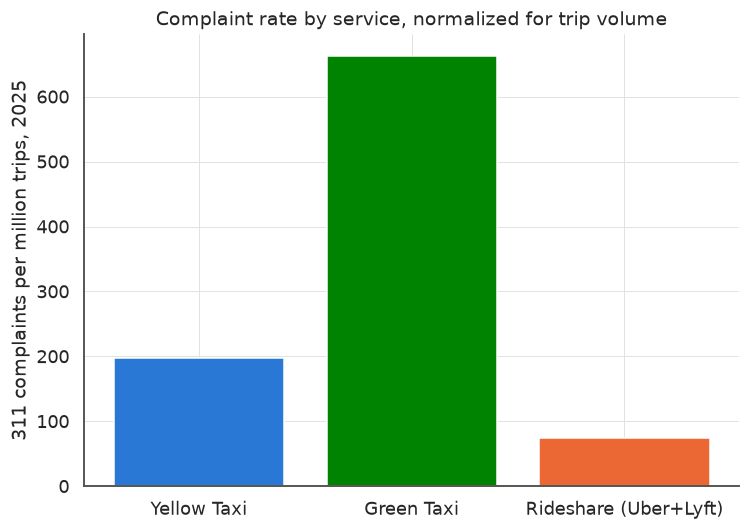

In [2]:
complaints = pd.read_csv(f"{DATA_DIR}/processed/tlc_311_complaints_2025.csv")

COMPLAINT_TYPE_TO_MODE = {
    "Taxi Complaint": "yellow",
    "Green Taxi Complaint": "green",
    "For Hire Vehicle Complaint": "rideshare",
}
complaints["service_mode"] = complaints["complaint_type"].map(COMPLAINT_TYPE_TO_MODE)
service_complaints = complaints.dropna(subset=["service_mode"]).copy()

print(f"Service complaints kept: {service_complaints['n'].sum()} / {complaints['n'].sum()} total 311 TLC records "
      f"(dropped: lost/found property, compliments, generic reports, licensee complaints)")

# 2025 trip totals, from the same pre-aggregated file the time-series notebook uses
daily = pd.read_csv(f"{DATA_DIR}/processed/daily_counts_by_mode_2025.csv")
trip_totals = daily.groupby("mode")["trip_count"].sum()
trip_totals["rideshare"] = trip_totals.get("uber", 0) + trip_totals.get("lyft", 0)

complaint_totals = service_complaints.groupby("service_mode")["n"].sum()
rate_tbl = pd.DataFrame({
    "total_trips_2025": trip_totals[["yellow", "green", "rideshare"]],
    "total_complaints_2025": complaint_totals,
})
rate_tbl["complaints_per_million_trips"] = rate_tbl["total_complaints_2025"] / rate_tbl["total_trips_2025"] * 1e6
rate_tbl.index = rate_tbl.index.map(MODE_LABELS)
print("\n=== Complaint rate per million trips, 2025 ===")
display(rate_tbl.round(2))

fig, ax = plt.subplots(figsize=(7, 5))
modes_order = ["yellow", "green", "rideshare"]
ax.bar(
    [MODE_LABELS[m] for m in modes_order],
    [rate_tbl.loc[MODE_LABELS[m], "complaints_per_million_trips"] for m in modes_order],
    color=[MODE_COLORS[m] for m in modes_order],
)
ax.set_ylabel("311 complaints per million trips, 2025")
ax.set_title("Complaint rate by service, normalized for trip volume")
fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/complaint_rate_per_million_trips_2025.png")
plt.show()

## 2. Wait-time and price complaints specifically

These are the two categories directly relevant to a "why do people switch to
rideshare" story -- wait/no-show complaints as a proxy for dispatch reliability,
fare/tip complaints as a proxy for pricing friction. Rates, not raw counts, again.

=== Wait-time-proxy and price-proxy complaint rates, 2025 ===


,wait_complaints,wait_per_million_trips,price_complaints,price_per_million_trips
service_mode,,,,
Green Taxi,52,87.93,92,155.58
Rideshare (Uber+Lyft),565,2.32,952,3.91
Yellow Taxi,542,11.12,3599,73.87


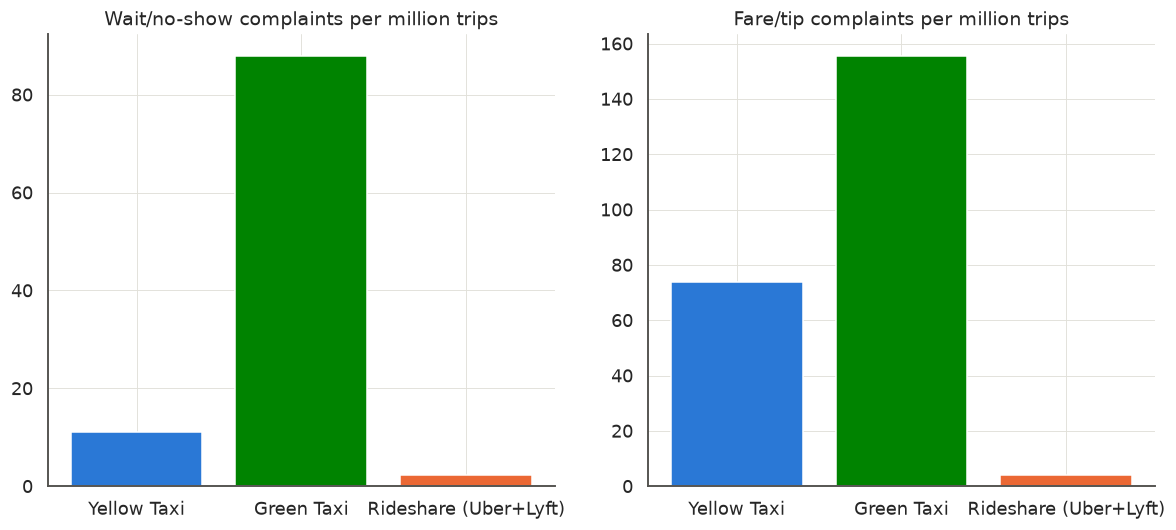

In [3]:
WAIT_DESCRIPTORS = ["Service Delay/No Show", "Refused Pick-Up", "Denied Request", "Drop-Off Refused"]
PRICE_PATTERN = r"Fare|Tip"

service_complaints["is_wait_proxy"] = service_complaints["descriptor_2"].isin(WAIT_DESCRIPTORS)
service_complaints["is_price_proxy"] = service_complaints["descriptor_2"].str.contains(PRICE_PATTERN, na=False, regex=True)

proxy_tbl = service_complaints.groupby("service_mode").apply(
    lambda g: pd.Series({
        "wait_complaints": g.loc[g["is_wait_proxy"], "n"].sum(),
        "price_complaints": g.loc[g["is_price_proxy"], "n"].sum(),
    }),
    include_groups=False,
)
proxy_tbl["total_trips_2025"] = trip_totals[["yellow", "green", "rideshare"]]
proxy_tbl["wait_per_million_trips"] = proxy_tbl["wait_complaints"] / proxy_tbl["total_trips_2025"] * 1e6
proxy_tbl["price_per_million_trips"] = proxy_tbl["price_complaints"] / proxy_tbl["total_trips_2025"] * 1e6
proxy_tbl.index = proxy_tbl.index.map(MODE_LABELS)

print("=== Wait-time-proxy and price-proxy complaint rates, 2025 ===")
display(proxy_tbl[["wait_complaints", "wait_per_million_trips", "price_complaints", "price_per_million_trips"]].round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
modes_order = ["yellow", "green", "rideshare"]
for ax, col, title in zip(axes, ["wait_per_million_trips", "price_per_million_trips"],
                            ["Wait/no-show complaints per million trips", "Fare/tip complaints per million trips"]):
    ax.bar([MODE_LABELS[m] for m in modes_order], [proxy_tbl.loc[MODE_LABELS[m], col] for m in modes_order],
           color=[MODE_COLORS[m] for m in modes_order])
    ax.set_title(title)
fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/wait_price_complaint_rates_2025.png")
plt.show()

## 3. Most frequent complaint words

**Caveat, stated plainly**: NYC 311 does not publish the rider's own words -- these
are word counts over the structured `descriptor` / `descriptor_2` category *labels*
(e.g. "Service Delay/No Show", "Unsafe Driving"), weighted by how many complaints
carry that label. It's a legitimate "what are people complaining about" visual, but
it's built from a fixed taxonomy TLC defined, not free-form rider narrative -- a real
sentiment/embeddings pipeline would need a different data source (e.g. scraped app
store reviews) to get actual rider language, with its own representativeness
caveats (self-selected, not NYC- or trip-specific).

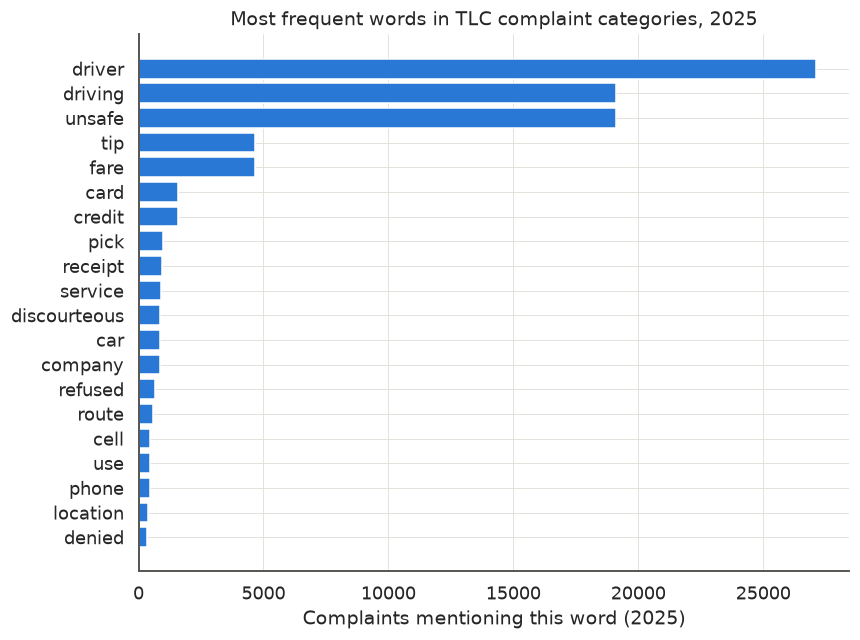

In [4]:
STOPWORDS = {"non", "passenger", "complaint", "unauthorized", "and", "or", "the", "a", "of", "to"}

def tokenize(text):
    return [w for w in re.findall(r"[a-z]+", str(text).lower()) if w not in STOPWORDS and len(w) > 2]

word_counts = Counter()
for _, row in service_complaints.iterrows():
    words = set(tokenize(row["descriptor"])) | set(tokenize(row["descriptor_2"]))  # once per complaint, not double-counted
    for w in words:
        word_counts[w] += row["n"]

top_words = pd.Series(word_counts).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_words.index[::-1], top_words.values[::-1], color="#2a78d6")
ax.set_xlabel("Complaints mentioning this word (2025)")
ax.set_title("Most frequent words in TLC complaint categories, 2025")
fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/complaint_word_frequency_2025.png")
plt.show()

## 4. Statistical testing at n = hundreds of thousands to millions

The problem: with daily data n=365, hourly n≈5,660-8,760, and raw trip-level data in
the tens/hundreds of millions, a p-value is a function of *both* effect size and n.
At this scale, n is so large that **any** nonzero effect -- including ones far too
small to act on -- clears p<0.001. A plain two-sample t-test or one-way ANOVA on
trip-level data would report "highly significant" for effects worth a fraction of a
percent. That makes "is it significant" the wrong question; **"how big is the
effect, and how precisely do we know that" is the one worth answering.**

There's a second, separate problem specific to this data: **autocorrelation**.
Daily/hourly trip counts are a time series -- today's count is highly correlated
with yesterday's (both reflect the same season, the same day-of-week rhythm from
section 2 of the time-series notebook). A t-test/ANOVA assumes independent
observations; violating that doesn't just make the p-value uselessly small, it can
make it *wrong* (typically anti-conservative -- falsely confident).

What we do about both, below:
1. **Report effect sizes, not just p-values** -- eta-squared (η²) for a categorical
   factor's share of variance explained, alongside the ANOVA.
2. **Move to a regression that fits the data**: trip counts are non-negative integer
   counts, not continuous/Gaussian, so a Negative Binomial GLM (not OLS/ANOVA) is the
   theoretically correct model -- and it lets us control day-of-week, weather, and
   events *jointly* in one model instead of many separate pairwise comparisons.
2b. Fit that GLM twice: once with default (iid-assuming) standard errors, once with
   **HAC (Newey-West) robust standard errors**, which are valid under
   autocorrelation -- shows directly how much the naive SEs understate uncertainty.
3. **Bootstrap confidence intervals** as a robustness check that doesn't rely on
   distributional assumptions at all.

On your subsampling idea specifically: shrinking n *just to move the p-value* isn't
a fix -- it doesn't change the true effect size, it only throws away precision, so
it's really just deliberately underpowering the test until it stops finding what's
actually there (the mirror image of p-hacking). The legitimate use of resampling
here is the opposite direction: **bootstrap resampling to build a confidence
interval that doesn't depend on normality**, which is what section 4.4 below does.

### 4.1 Effect size alongside ANOVA: does day-of-week actually matter, and how much?

One-way ANOVA on daily total trips grouped by day-of-week will trivially reject the
null (n=365, and we already know from the weekly-profile chart that weekday does
matter) -- the p-value adds nothing. **Eta-squared (η²)** answers the question that
matters: what share of the variance in daily trip counts does day-of-week explain?
(Conventional benchmarks: η² ≈ 0.01 small, 0.06 medium, 0.14 large.)

In [5]:
from scipy import stats

daily = pd.read_csv(f"{DATA_DIR}/processed/daily_counts_by_mode_2025.csv", parse_dates=["pickup_date"])
daily_wide = daily.pivot(index="pickup_date", columns="mode", values="trip_count").fillna(0)
daily_wide["total"] = daily_wide.sum(axis=1)
daily_wide["dow"] = daily_wide.index.day_name()

groups = [g["total"].values for _, g in daily_wide.groupby("dow")]
f_stat, p_val = stats.f_oneway(*groups)

grand_mean = daily_wide["total"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total = ((daily_wide["total"] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total

print(f"One-way ANOVA, daily total trips ~ day-of-week: F={f_stat:.1f}, p={p_val:.2e}")
print(f"Eta-squared: {eta_sq:.3f}  -> day-of-week explains {eta_sq:.1%} of the variance in daily trip counts")
print("(p alone would just say 'yes, obviously' at this n; eta-squared says how much it actually matters)")

One-way ANOVA, daily total trips ~ day-of-week: F=66.6, p=2.49e-55
Eta-squared: 0.527  -> day-of-week explains 52.7% of the variance in daily trip counts
(p alone would just say 'yes, obviously' at this n; eta-squared says how much it actually matters)


### 4.2 Negative Binomial regression: the theoretically correct model for count data

Trip counts are non-negative integers with variance that grows with the mean
(overdispersion) -- not a continuous Gaussian quantity, so OLS/ANOVA's assumptions
don't really fit. A **Negative Binomial GLM** models the count directly, and its
coefficients exponentiate to an **Incidence Rate Ratio (IRR)**: "a 1-unit increase
in X multiplies expected trip count by this factor" -- a genuine effect size with a
confidence interval, not a bare p-value. Day-of-week is included as a control so the
weather effect isn't just re-detecting the weekly rhythm from section 2.

Fit twice: once with the model's default (independence-assuming) standard errors,
once with **HAC (Newey-West) robust** standard errors, which stay valid under the
autocorrelation daily trip counts actually have. The gap between the two SE columns
*is* the size of the mistake a naive t-test/ANOVA on this data would be making.

In [6]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

daily_wx = pd.read_csv(f"{DATA_DIR}/processed/daily_weather_2025.csv", parse_dates=["date"])
reg_df = daily_wide.reset_index().rename(columns={"pickup_date": "date"})
reg_df = reg_df.merge(daily_wx[["date", "temp_c_mean", "precip_mm_total"]], on="date", how="left").dropna()

FORMULA = "total ~ C(dow) + temp_c_mean + precip_mm_total"

# Step 1: MLE Negative Binomial to estimate the dispersion parameter (alpha) from the data
nb_mle = smf.negativebinomial(FORMULA, data=reg_df).fit(disp=0)
alpha_hat = nb_mle.params["alpha"]
print(f"Estimated NB dispersion alpha = {alpha_hat:.3f} (alpha > 0 confirms real overdispersion vs a plain Poisson)")

# Step 2: refit as a GLM with that alpha, so we can request HAC-robust covariance
nb_family = sm.families.NegativeBinomial(alpha=alpha_hat)
glm_default = smf.glm(FORMULA, data=reg_df, family=nb_family).fit()
glm_hac = smf.glm(FORMULA, data=reg_df, family=nb_family).fit(cov_type="HAC", cov_kwds={"maxlags": 7})

WEATHER_VARS = ["temp_c_mean", "precip_mm_total"]
comparison = pd.DataFrame({
    "IRR": np.exp(glm_default.params[WEATHER_VARS]),
    "default_SE": glm_default.bse[WEATHER_VARS],
    "default_CI_low": np.exp(glm_default.conf_int().loc[WEATHER_VARS, 0]),
    "default_CI_high": np.exp(glm_default.conf_int().loc[WEATHER_VARS, 1]),
    "HAC_SE": glm_hac.bse[WEATHER_VARS],
    "HAC_CI_low": np.exp(glm_hac.conf_int().loc[WEATHER_VARS, 0]),
    "HAC_CI_high": np.exp(glm_hac.conf_int().loc[WEATHER_VARS, 1]),
})
print("\n=== Weather effect on daily total trips: IRR = 'multiply expected trips by this, per unit of X' ===")
print("(controlling for day-of-week; SE/CI shown both ways so the autocorrelation cost is visible)")
display(comparison.round(4))
print(f"\nSE inflation under HAC: temp {comparison.loc['temp_c_mean','HAC_SE']/comparison.loc['temp_c_mean','default_SE']:.2f}x, "
      f"precip {comparison.loc['precip_mm_total','HAC_SE']/comparison.loc['precip_mm_total','default_SE']:.2f}x")

Estimated NB dispersion alpha = 0.006 (alpha > 0 confirms real overdispersion vs a plain Poisson)

=== Weather effect on daily total trips: IRR = 'multiply expected trips by this, per unit of X' ===
(controlling for day-of-week; SE/CI shown both ways so the autocorrelation cost is visible)


/home/cjboi/MAST30034_Python/.proj1/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,IRR,default_SE,default_CI_low,default_CI_high,HAC_SE,HAC_CI_low,HAC_CI_high
temp_c_mean,0.9981,0.0004,0.9973,0.9989,0.0010,0.9961,1.0001
precip_mm_total,1.0024,0.0005,1.0014,1.0035,0.0004,1.0016,1.0033



SE inflation under HAC: temp 2.50x, precip 0.82x


### 4.3 Bootstrap confidence interval: resampling used the right way round

Rather than subsampling *down* to weaken the test, bootstrap resamples *with
replacement* at the natural unit of observation (a day, not a trip -- resampling
individual trips would pretend each trip is an independent observation, which is
exactly the assumption we're trying to avoid) to build an empirical confidence
interval for "% change in trips on a rain day" that doesn't assume normality at all.
2,000 resamples of the 365 days, each time recomputing the rain-day vs dry-day %
difference; the interval is just the 2.5th-97.5th percentile of that distribution.

Rain days in 2025: 121 / 365



Bootstrap estimate: rain days have +4.0% total trips vs dry days (95% CI: +1.6% to +6.6%, 2000 valid resamples)
CI excludes 0


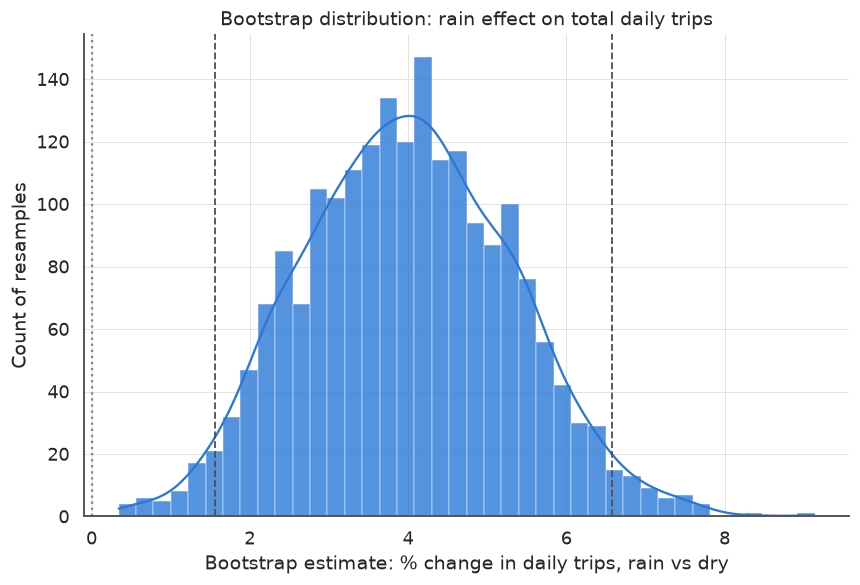

In [7]:
boot_df = reg_df.merge(daily_wx[["date", "is_rain_day"]], on="date", how="left")
n_rain_days = int(boot_df["is_rain_day"].sum())
print(f"Rain days in 2025: {n_rain_days} / {len(boot_df)}")

rng = np.random.default_rng(30034)
N_BOOT = 2000
boot_diffs = []
for _ in range(N_BOOT):
    sample = boot_df.sample(n=len(boot_df), replace=True, random_state=rng.integers(0, 2**31 - 1))
    rain_mean = sample.loc[sample["is_rain_day"], "total"].mean()
    dry_mean = sample.loc[~sample["is_rain_day"], "total"].mean()
    if pd.notna(rain_mean) and pd.notna(dry_mean) and dry_mean > 0:
        boot_diffs.append((rain_mean - dry_mean) / dry_mean * 100)

boot_diffs = np.array(boot_diffs)
ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
point_est = boot_diffs.mean()
print(f"\nBootstrap estimate: rain days have {point_est:+.1f}% total trips vs dry days "
      f"(95% CI: {ci_low:+.1f}% to {ci_high:+.1f}%, {len(boot_diffs)} valid resamples)")
print("CI excludes 0" if (ci_low > 0) or (ci_high < 0) else "CI includes 0 -- not distinguishable from no effect at this confidence level")

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.histplot(boot_diffs, bins=40, color="#2a78d6", alpha=0.8, kde=True, ax=ax, edgecolor="white", linewidth=0.3)
ax.axvline(0, color="#898781", linestyle=":", linewidth=1.5)
ax.axvline(ci_low, color="#52514e", linestyle="--", linewidth=1.2)
ax.axvline(ci_high, color="#52514e", linestyle="--", linewidth=1.2)
ax.set_xlabel("Bootstrap estimate: % change in daily trips, rain vs dry")
ax.set_ylabel("Count of resamples")
ax.set_title("Bootstrap distribution: rain effect on total daily trips")
fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/bootstrap_rain_effect_2025.png")
plt.show()

### Summary for the report

- Don't lead with p-values at this n -- lead with effect sizes (η², IRR, % change)
  and confidence intervals; note in the methods section *why* (n this large makes
  p-values uninformative about practical importance).
- Trip counts are count data -- a Negative Binomial GLM is the correct model family,
  not OLS/ANOVA on raw counts.
- Daily/hourly observations are autocorrelated -- HAC-robust SEs (or block
  bootstrap) are needed for valid inference; naive SEs understate uncertainty.
- Subsampling to shrink n doesn't fix anything -- it just discards precision.
  Bootstrap resampling *for a distribution-free CI* is the legitimate technique in
  that family, and it's used above the right way round (resampling the natural
  unit of observation -- days -- not raw trips).